# Phase 4 - Evaluation et Comparaison
Comparaison des 4 modeles sur un jeu de test identique.
Metriques: accuracy, precision, recall, f1, roc-auc, pr-auc, matrice de confusion.

## Phase 5 - Interpretabilite
Feature importances (arbres), permutation importance, et SHAP pour le modele final.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [2]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'customer_churn.csv').exists():
            return candidate
    raise FileNotFoundError('Impossible de localiser data/customer_churn.csv')

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'customer_churn.csv'

df = pd.read_csv(DATA_PATH)
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

target_col = 'churn'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
def apply_feature_engineering(data):
    temp = data.copy()
    if 'tenure_months' in temp.columns:
        tenure_safe = temp['tenure_months'].replace(0, np.nan)
    else:
        tenure_safe = None

    if {'support_tickets', 'tenure_months'}.issubset(temp.columns):
        temp['tickets_per_tenure'] = (temp['support_tickets'] / tenure_safe).fillna(0)
    if {'total_revenue', 'tenure_months'}.issubset(temp.columns):
        temp['revenue_per_month'] = (temp['total_revenue'] / tenure_safe).fillna(0)
    if {'payment_failures', 'tenure_months'}.issubset(temp.columns):
        temp['payment_failure_rate'] = (temp['payment_failures'] / tenure_safe).fillna(0)
    return temp

X_train = apply_feature_engineering(X_train)
X_test = apply_feature_engineering(X_test)

In [4]:
def build_preprocessor(X_sample, scaled: bool):
    num_cols = X_sample.select_dtypes(include=['number', 'bool']).columns.tolist()
    cat_cols = X_sample.select_dtypes(exclude=['number', 'bool']).columns.tolist()

    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scaled:
        num_steps.append(('scaler', StandardScaler()))

    num_pipe = Pipeline(steps=num_steps)
    cat_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])
    return preprocessor

In [5]:
model_specs = {
    'Logistic Regression': {'model': LogisticRegression(max_iter=1000), 'scaled': True},
    'Random Forest': {'model': RandomForestClassifier(n_estimators=300, random_state=42), 'scaled': False},
    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        'scaled': False
    },
    'MLP': {
        'model': MLPClassifier(
            hidden_layer_sizes=(32, 16),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
        'scaled': True
    }
}

In [6]:
def get_scores(estimator, X):
    if hasattr(estimator, 'predict_proba'):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, 'decision_function'):
        return estimator.decision_function(X)
    return None

models = {}
rows = []

for name, spec in model_specs.items():
    pre = build_preprocessor(X_train, scaled=spec['scaled'])
    pipeline = ImbPipeline([
        ('pre', pre),
        ('smote', SMOTE(random_state=42)),
        ('model', spec['model'])
    ])
    pipeline.fit(X_train, y_train)
    models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_score = get_scores(pipeline, X_test)

    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
        'PR-AUC': average_precision_score(y_test, y_score) if y_score is not None else np.nan
    })

results_df = pd.DataFrame(rows).set_index('Model')
display(results_df.sort_values('Recall', ascending=False))

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.6760,0.185552,0.642157,0.287912,0.718331,0.235094
MLP,0.7985,0.214900,0.367647,0.271248,0.683458,0.190328
XGBoost,0.8890,0.320000,0.078431,0.125984,0.780351,0.264390
Random Forest,0.8975,0.333333,0.004902,0.009662,0.794029,0.287834


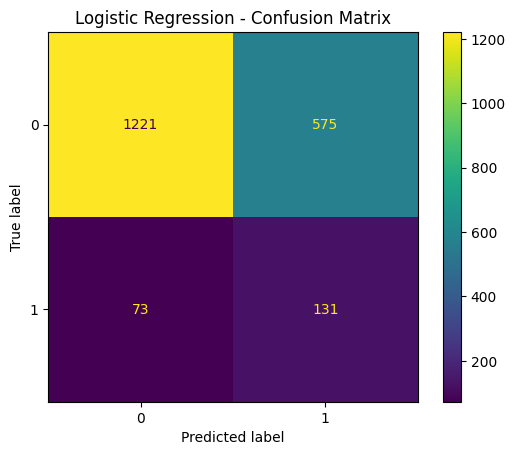

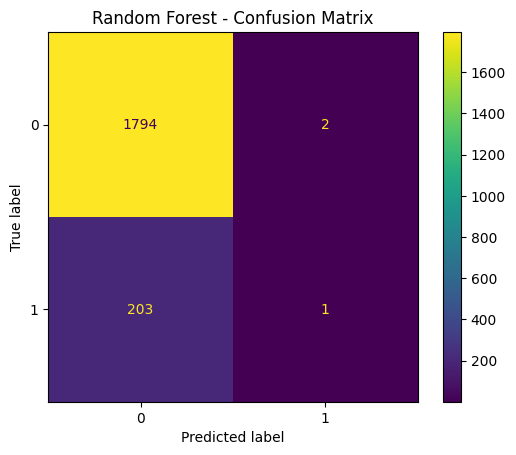

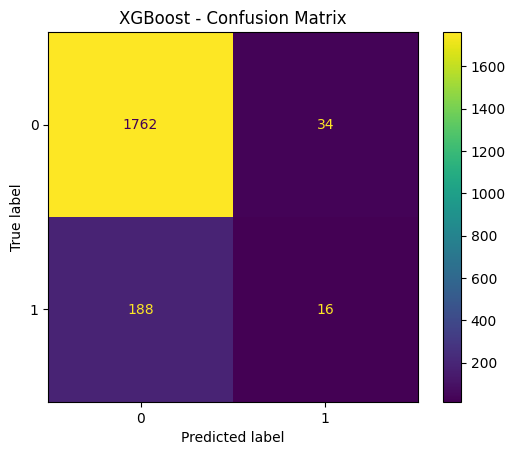

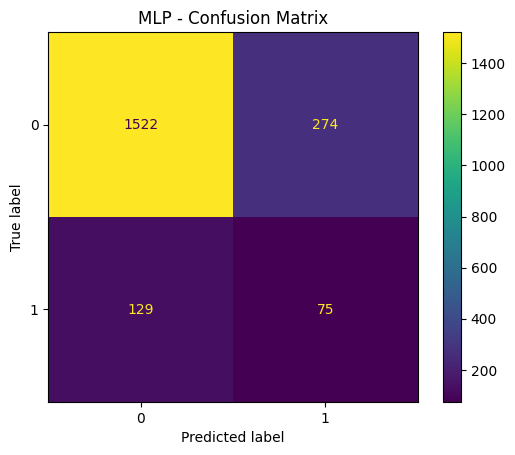

In [7]:
# Matrice de confusion pour chaque modele
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

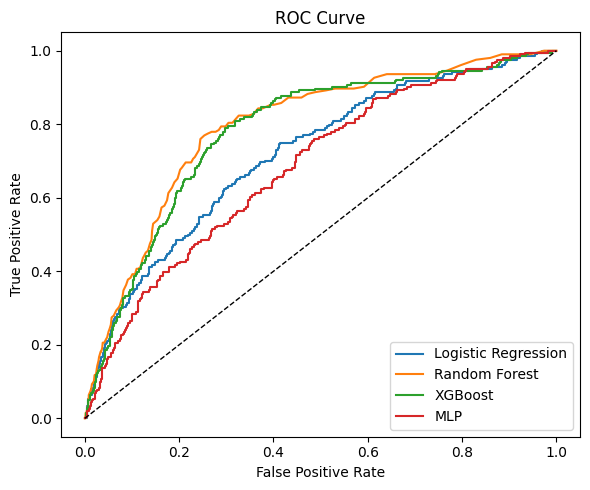

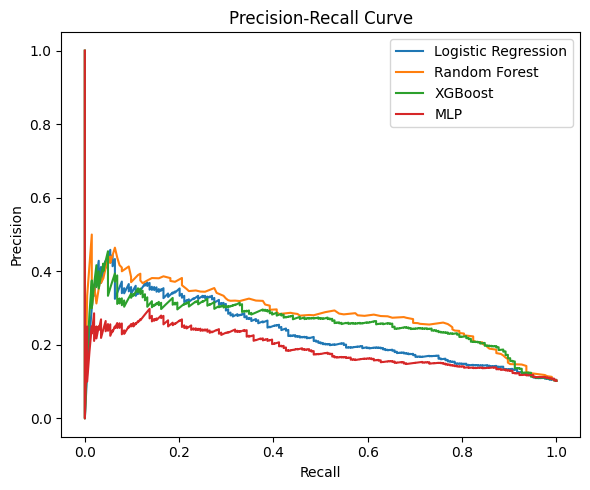

In [8]:
# Courbes ROC et PR
plt.figure(figsize=(6, 5))
for name, pipeline in models.items():
    y_score = get_scores(pipeline, X_test)
    if y_score is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
for name, pipeline in models.items():
    y_score = get_scores(pipeline, X_test)
    if y_score is None:
        continue
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    plt.plot(recall, precision, label=name)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Feature importances pour les modeles a arbres
for name in ['Random Forest', 'XGBoost']:
    if name not in models:
        continue
    pipeline = models[name]
    feature_names = pipeline.named_steps['pre'].get_feature_names_out()
    importances = pipeline.named_steps['model'].feature_importances_
    imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    display(imp_series.head(15))

num__csat_score                   0.085940
num__payment_failures             0.059606
num__tenure_months                0.042238
num__payment_failure_rate         0.041122
cat__signup_channel_Web           0.036349
cat__complaint_type_Technical     0.031719
cat__discount_applied_Yes         0.031177
cat__payment_method_Card          0.030815
cat__contract_type_Monthly        0.028728
cat__discount_applied_No          0.027895
cat__survey_response_Satisfied    0.026345
cat__gender_Female                0.026050
num__total_revenue                0.025553
cat__gender_Male                  0.025311
cat__survey_response_Neutral      0.022521
dtype: float64

num__csat_score                     0.096867
cat__gender_Male                    0.096484
cat__discount_applied_Yes           0.090643
cat__signup_channel_Web             0.075050
cat__survey_response_Neutral        0.056710
cat__complaint_type_Technical       0.052790
num__payment_failures               0.044626
cat__contract_type_Monthly          0.041117
cat__survey_response_Satisfied      0.036934
cat__payment_method_Card            0.036204
cat__customer_segment_Individual    0.022288
cat__signup_channel_Mobile          0.020767
cat__contract_type_Quarterly        0.020288
cat__discount_applied_No            0.020107
cat__customer_segment_SME           0.018792
dtype: float32

In [10]:
# Permutation importance (modele avec meilleur recall)
best_model_name = results_df.sort_values('Recall', ascending=False).index[0]
best_pipeline = models[best_model_name]

perm_result = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='recall'
 )

perm_names = best_pipeline.named_steps['pre'].get_feature_names_out()
perm_df = pd.Series(perm_result.importances_mean, index=perm_names)
display(perm_df.sort_values(ascending=False).head(15))

ValueError: Length of values (33) does not match length of index (60)

## SHAP (modele final)
Active cette partie pour le meilleur modele. Si SHAP n'est pas installe: pip install shap

In [ ]:
run_shap = False
if run_shap:
    import shap
    best_model_name = results_df.sort_values('Recall', ascending=False).index[0]
    best_pipeline = models[best_model_name]
    model = best_pipeline.named_steps['model']
    X_test_transformed = best_pipeline.named_steps['pre'].transform(X_test)
    feature_names = best_pipeline.named_steps['pre'].get_feature_names_out()

    explainer = shap.Explainer(model, X_test_transformed, feature_names=feature_names)
    shap_values = explainer(X_test_transformed)

    shap.summary_plot(shap_values, feature_names=feature_names)
    shap.waterfall_plot(shap_values[0])
    shap.dependence_plot(0, shap_values.values, X_test_transformed, feature_names=feature_names)